<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

In [3]:
import fastai
from fastai import *
from fastai.vision import *
from fastai.vision.all import *
from fastai.losses import MSELossFlat, CrossEntropyLossFlat
import timm
import PIL
from torchvision import transforms

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

## Modelos

### Resnet 50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=128)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.004365158267319202)

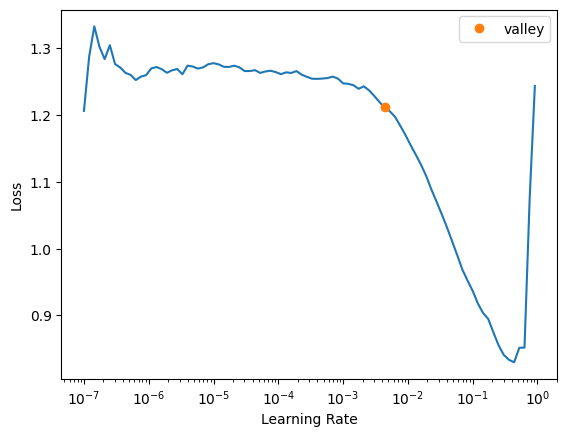

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.134718,0.111616,0.977699,0.000000,0.000000,0.000000,08:48


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11161649227142334.


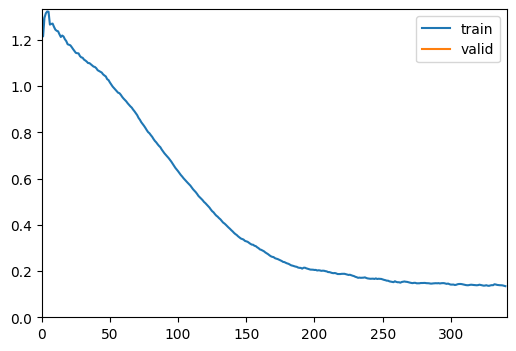

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.105737,0.135013,0.977699,0.000000,0.000000,0.000000,09:04
1,0.113950,0.282286,0.977699,0.000000,0.000000,0.000000,09:04
2,0.112792,0.106755,0.977699,0.000000,0.000000,0.000000,09:10
3,0.099973,0.108033,0.977699,0.000000,0.000000,0.000000,09:09
4,0.098181,0.109675,0.977699,0.000000,0.000000,0.000000,09:02
5,0.098691,0.103121,0.977699,0.000000,0.000000,0.000000,08:51
6,0.096698,0.097624,0.977699,0.500000,0.004098,0.008130,08:40
7,0.089409,0.101533,0.977424,0.440000,0.045082,0.081784,08:49
8,0.088965,0.099235,0.977333,0.437500,0.057377,0.101449,09:03
9,0.088852,0.097297,0.977699,0.500000,0.036885,0.068702,08:59


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1350134015083313.


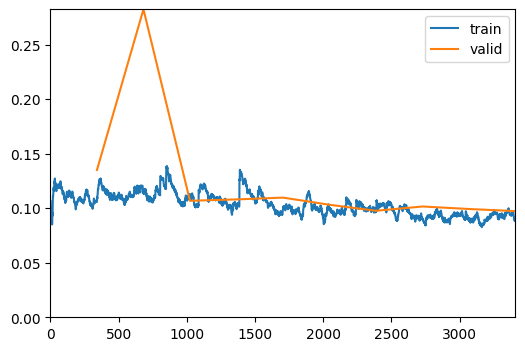

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.10675548017024994.


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.10312093794345856.
Better model found at epoch 6 with valid_loss value: 0.09762357920408249.
Better model found at epoch 9 with valid_loss value: 0.09729737788438797.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 40 mins.

### EfficientNet

Para que la ejecució quepa en la caché, hay que reducir los tamaños de las imágenes y el batch.

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
import torch
torch.cuda.empty_cache()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.157429,0.123083,0.979527,0.000000,0.000000,0.000000,09:34


Better model found at epoch 0 with valid_loss value: 0.12308338284492493.


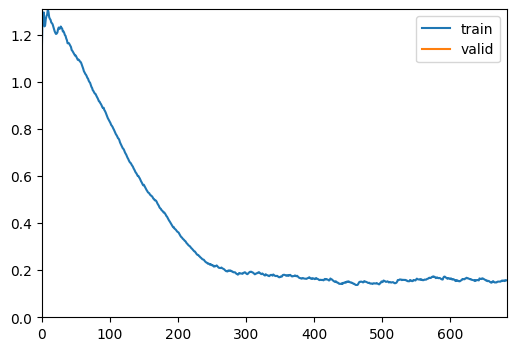

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.109194,0.098137,0.980441,0.000000,0.000000,0.000000,09:29
1,0.114298,0.099628,0.980441,0.000000,0.000000,0.000000,09:19
2,0.125833,0.099406,0.980441,0.000000,0.000000,0.000000,09:17
3,0.109041,0.095146,0.980441,0.000000,0.000000,0.000000,09:16
4,0.103849,0.098076,0.980441,0.000000,0.000000,0.000000,09:19
5,0.088844,0.095915,0.980441,0.000000,0.000000,0.000000,09:19
6,0.107047,nan,0.980441,0.000000,0.000000,0.000000,09:19
7,0.106938,nan,0.980441,0.000000,0.000000,0.000000,09:28
8,0.091529,0.092460,0.980441,0.000000,0.000000,0.000000,09:36
9,0.101932,0.092285,0.980441,0.000000,0.000000,0.000000,09:33


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09813690185546875.


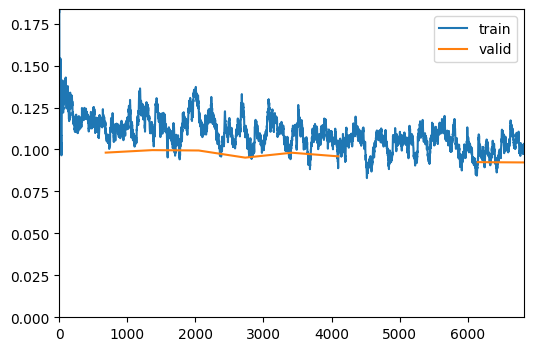

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09514576196670532.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Better model found at epoch 8 with valid_loss value: 0.09245970100164413.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 9 with valid_loss value: 0.09228470921516418.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 44 mins.

### ConvNext

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:07<00:00, 45.9MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.154840,0.114093,0.980258,0.000000,0.000000,0.000000,09:11


Better model found at epoch 0 with valid_loss value: 0.11409283429384232.


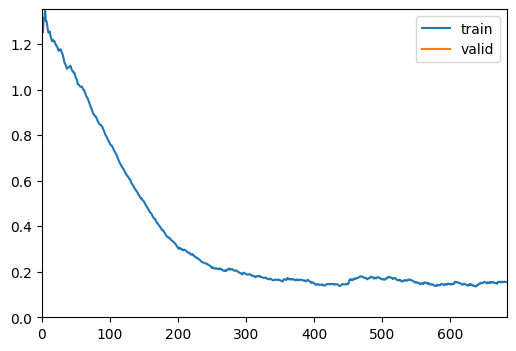

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.097386,0.097244,0.980441,0.000000,0.000000,0.000000,09:37
1,0.124461,0.116928,0.980441,0.000000,0.000000,0.000000,09:37
2,0.101866,0.100506,0.980441,0.000000,0.000000,0.000000,09:35
3,0.108117,0.091792,0.980441,0.000000,0.000000,0.000000,09:36
4,0.100571,0.094839,0.980441,0.000000,0.000000,0.000000,09:36
5,0.107470,0.090112,0.980441,0.000000,0.000000,0.000000,09:37
6,0.107873,0.088212,0.980898,0.857143,0.028037,0.054299,09:39
7,0.106709,0.086807,0.980532,0.538462,0.032710,0.061674,09:30
8,0.096510,0.085968,0.980898,0.857143,0.028037,0.054299,09:29
9,0.099173,0.086072,0.980623,0.600000,0.028037,0.053571,09:28


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09724444150924683.


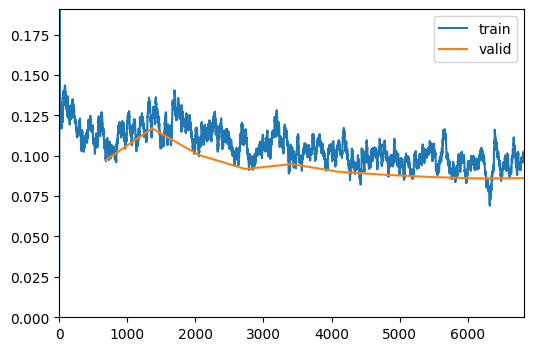

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09179195761680603.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.09011197090148926.
Better model found at epoch 6 with valid_loss value: 0.08821216225624084.
Better model found at epoch 7 with valid_loss value: 0.08680716902017593.
Better model found at epoch 8 with valid_loss value: 0.08596846461296082.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 45 mins.

### Hrnet

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=32)

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-hrnet/hrnetv2_w44-c9ac8c18.pth" to /root/.cache/torch/hub/checkpoints/hrnetv2_w44-c9ac8c18.pth


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.144876,0.131406,0.976236,0.000000,0.000000,0.000000,12:44


Better model found at epoch 0 with valid_loss value: 0.13140591979026794.


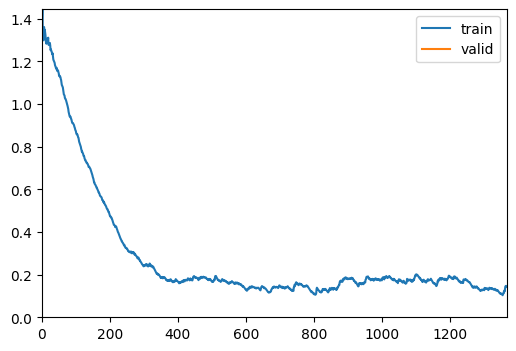

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.099613,0.123273,0.976328,0.000000,0.000000,0.000000,14:00
1,0.126929,0.126066,0.976328,0.000000,0.000000,0.000000,14:00
2,0.118984,0.112464,0.976328,0.000000,0.000000,0.000000,14:10
3,0.114417,0.116200,0.976328,0.000000,0.000000,0.000000,13:59
4,0.103200,0.240522,0.974043,0.000000,0.000000,0.000000,13:58
5,0.095524,1.490318,0.974500,0.000000,0.000000,0.000000,13:55
6,0.101700,nan,0.976328,0.000000,0.000000,0.000000,13:54
7,0.073411,nan,0.976510,0.625000,0.019305,0.037453,13:52
8,0.094232,0.105128,0.976419,0.555556,0.019305,0.037313,13:52
9,0.097534,nan,0.976510,0.625000,0.019305,0.037453,13:50


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.12327256053686142.


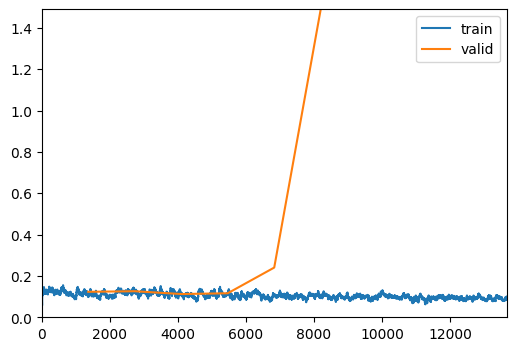

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.11246427148580551.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 8 with valid_loss value: 0.10512750595808029.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

2 horas 33 minutos.

### Deit

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(384), # Solo funciona con este tamaño
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=8)

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h solo en la primera época, por lo que se espera que tarde 10 horas.

## Balanceo

In [6]:
df

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54701,1,9973,1729524723,R,MLO,43.0,0,0,0,1.0,0,C,49,False
54702,1,9989,63473691,L,MLO,60.0,0,0,0,NaN,0,C,216,False
54703,1,9989,1078943060,L,CC,60.0,0,0,0,NaN,0,C,216,False
54704,1,9989,398038886,R,MLO,60.0,0,0,0,0.0,0,C,216,True


In [7]:
tam = df.loc[df["cancer"] == 1]["patient_id"].unique().size

In [8]:
X = df.loc[::, df.columns.drop("cancer")].copy()
y = df.loc[::, "cancer"].copy()

In [9]:
y.value_counts()

0    53548
1     1158
Name: cancer, dtype: int64

Los datos están claramente desbalanceados. Se va a escoger al azar los elementos de la clase mayoritaria para entrenar a los modelos.

In [10]:
np.random.seed(0)
patients = np.random.choice(df.loc[df["cancer"] == 0]["patient_id"], tam)
patients = np.concatenate((patients, df.loc[df["cancer"] == 1]["patient_id"].unique()))
patients.size

972

In [11]:
dfb = df.loc[df["patient_id"].isin(patients)].copy()

In [12]:
dfb

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
87,1,10130,388811999,L,MLO,71.0,1,1,1,0.0,0,B,49,False
88,1,10130,613462606,L,CC,71.0,1,1,1,0.0,0,B,49,False
89,1,10130,1360338805,L,CC,71.0,1,1,1,0.0,0,B,49,False
90,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False
91,1,10130,1013166704,R,CC,71.0,0,0,0,NaN,0,B,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54598,2,9851,1945262248,R,MLO,58.0,0,0,0,NaN,0,NaN,48,False
54625,1,9894,564726178,L,CC,50.0,0,1,0,0.0,0,B,49,True
54626,1,9894,942623950,L,MLO,50.0,0,1,0,0.0,0,B,49,True
54627,1,9894,1991772614,R,CC,50.0,0,1,0,0.0,0,B,49,True


In [13]:
import os
import shutil

p_under = path/"undersampled"

if not os.path.isdir(p_under):
    os.mkdir(p_under)

for index, row in dfb.iterrows():
    patient = row["patient_id"]
    shutil.copytree(imagesPath/str(patient), p_under/str(patient), dirs_exist_ok=True)

In [14]:
def cadena2(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func2(fname):
    return dfb.loc[dfb['image_id'] == int(cadena2(fname.name))]['cancer'].values[0]

## Modelos undersampling

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.182381,0.684254,0.675764,0.282178,0.272727,0.277372,01:14


Better model found at epoch 0 with valid_loss value: 0.6842542290687561.


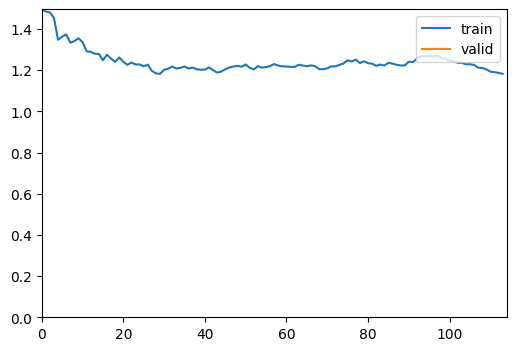

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.861584,0.600201,0.740175,0.340659,0.148325,0.206667,01:25
1,0.809583,0.651712,0.770742,0.400000,0.009569,0.018692,01:26
2,0.750382,0.548378,0.763100,0.404762,0.081340,0.135458,01:26
3,0.719044,0.580735,0.771834,0.500000,0.004785,0.009479,01:25


Better model found at epoch 0 with valid_loss value: 0.6002006530761719.


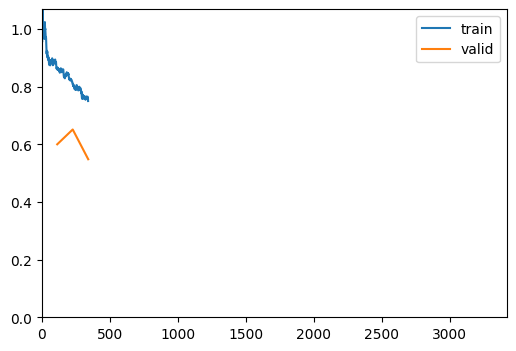

Better model found at epoch 2 with valid_loss value: 0.5483778119087219.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 7 mins.

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 73.2MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.074252,nan,0.757642,0.333333,0.062201,0.104839,01:35


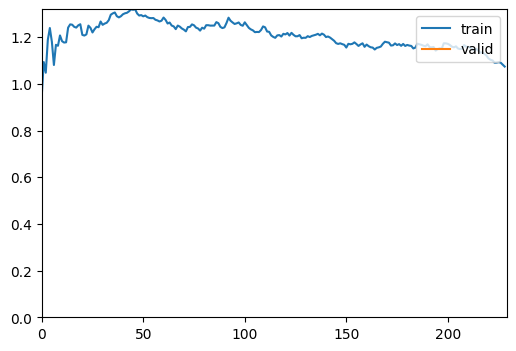

FileNotFoundError: ignored

In [ ]:
learn.fine_tune(30, base_lr=1e-3)

No sé por qué no funciona.

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:06<00:00, 54.8MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.041896,0.739255,0.742358,0.333333,0.129187,0.186207,03:09


Better model found at epoch 0 with valid_loss value: 0.7392553091049194.


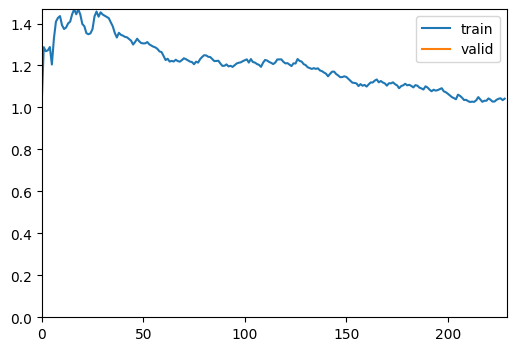

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.803352,0.641517,0.776201,0.562500,0.086124,0.149378,03:58
1,0.771936,0.561804,0.730349,0.360294,0.234450,0.284058,03:58
2,0.725425,0.686403,0.777293,1.000000,0.023923,0.046729,03:58
3,0.750516,0.557713,0.757642,0.372549,0.090909,0.146154,03:58
4,0.670676,0.650633,0.776201,0.833333,0.023923,0.046512,03:58


Better model found at epoch 0 with valid_loss value: 0.6415166258811951.


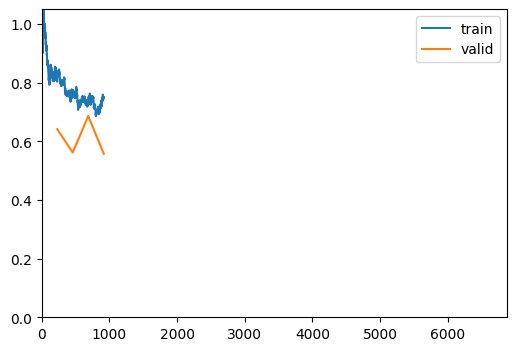

Better model found at epoch 1 with valid_loss value: 0.561804473400116.
Better model found at epoch 3 with valid_loss value: 0.5577128529548645.
No improvement since epoch 1: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 23 minutos.

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.931272,0.715426,0.732533,0.290698,0.119617,0.169492,04:42


Better model found at epoch 0 with valid_loss value: 0.7154256105422974.


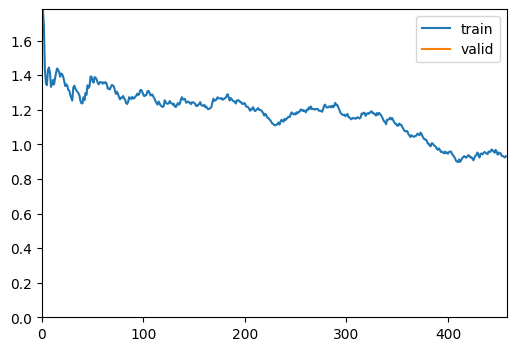

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.701617,0.577592,0.741266,0.337209,0.138756,0.196610,06:16
1,0.698727,0.561044,0.735808,0.305882,0.124402,0.176871,06:16
2,0.656262,0.551533,0.768559,0.285714,0.009569,0.018519,06:17
3,0.629854,0.571239,0.695415,0.208333,0.119617,0.151976,06:17


Better model found at epoch 0 with valid_loss value: 0.5775920748710632.


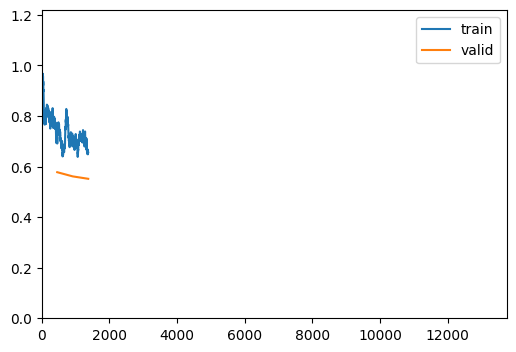

Better model found at epoch 1 with valid_loss value: 0.5610436797142029.
Better model found at epoch 2 with valid_loss value: 0.5515329837799072.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

30 minutos.

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.981733,0.662352,0.705240,0.292517,0.205742,0.241573,01:44


Better model found at epoch 0 with valid_loss value: 0.662351667881012.


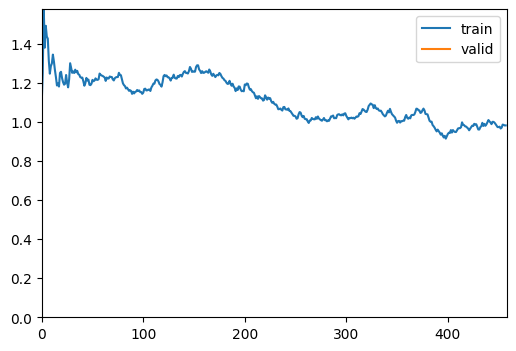

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.721167,0.557858,0.754367,0.421569,0.205742,0.276527,02:21
1,0.715758,0.558038,0.733624,0.364341,0.224880,0.278107,02:21
2,0.648156,0.552422,0.757642,0.432990,0.200957,0.274510,02:21
3,0.649120,0.559785,0.736900,0.387324,0.263158,0.313390,02:21
4,0.594278,0.533125,0.759825,0.447619,0.224880,0.299363,02:22
5,0.574233,0.508104,0.768559,0.483516,0.210526,0.293333,02:21
6,0.573295,0.505712,0.767467,0.486667,0.349282,0.406685,02:22
7,0.581476,0.520290,0.767467,0.487952,0.387560,0.432000,02:20
8,0.567518,0.483228,0.802402,0.600000,0.401914,0.481375,02:21
9,0.497354,0.483892,0.783843,0.542636,0.334928,0.414201,02:21


Better model found at epoch 0 with valid_loss value: 0.557857871055603.


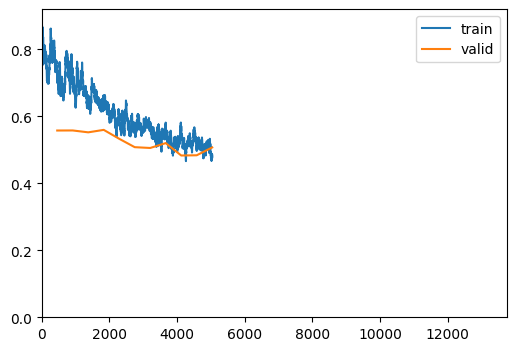

Better model found at epoch 2 with valid_loss value: 0.5524224638938904.
Better model found at epoch 4 with valid_loss value: 0.5331253409385681.
Better model found at epoch 5 with valid_loss value: 0.508103609085083.
Better model found at epoch 6 with valid_loss value: 0.50571209192276.
Better model found at epoch 8 with valid_loss value: 0.4832279682159424.
Better model found at epoch 11 with valid_loss value: 0.47656822204589844.
No improvement since epoch 8: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

30 minutos.

## Balanceo v2

Esta vez se a a probar a balancear por imagenes en vez de por pacientes a ver qué ocurre.

In [15]:
tam = df.loc[df["cancer"] == 1]["image_id"].size

In [16]:
np.random.seed(0)
images = df.loc[df["cancer"] == 1]["image_id"]
images = np.concatenate((images, np.random.choice(df.loc[df["cancer"] == 0]["image_id"], tam)))
images.size

2316

In [17]:
dfb2 = df.loc[df["image_id"].isin(images)].copy()

In [18]:
dfb2["cancer"].value_counts()

1    1158
0    1147
Name: cancer, dtype: int64

In [19]:
import os
import shutil

p_under2 = path/"undersampled_v2"

if not os.path.isdir(p_under2):
    os.mkdir(p_under2)

for index, row in dfb2.iterrows():
    patient = row["patient_id"]
    if not os.path.isdir(p_under2/str(patient)):
        os.mkdir(p_under2/str(patient))
    image = row["image_id"]
    src = imagesPath/str(patient)/(str(image)+'.jpg')
    dst = p_under2/str(patient)/(str(image)+'.jpg')
    shutil.copyfile(src, dst)

In [20]:
def cadena3(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func3(fname):
    return dfb2.loc[dfb2['image_id'] == int(cadena3(fname.name))]['cancer'].values[0]

## Modelos undersampling v2

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.319444,2.047321,0.537961,0.530892,0.966667,0.685377,00:42


Better model found at epoch 0 with valid_loss value: 2.04732084274292.


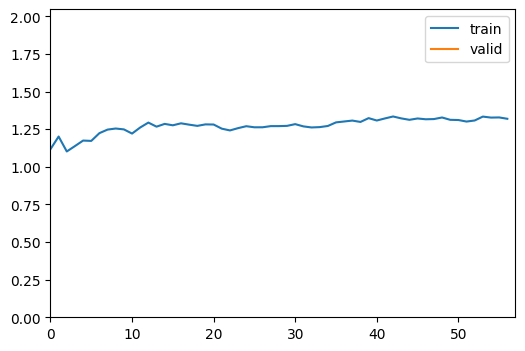

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.067761,0.924267,0.563991,0.572491,0.641667,0.605108,00:42
1,1.043945,0.798499,0.574837,0.588710,0.608333,0.598361,00:43
2,0.964636,0.886527,0.503254,0.522088,0.541667,0.531697,00:45
3,0.939635,0.873033,0.531453,0.600000,0.300000,0.400000,00:43


Better model found at epoch 0 with valid_loss value: 0.9242668747901917.


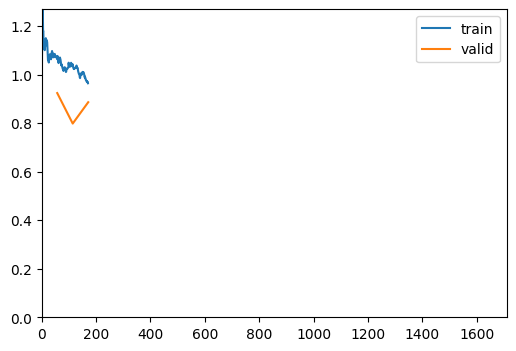

Better model found at epoch 1 with valid_loss value: 0.7984985709190369.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 3 minutos y medio.

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 69.5MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.315400,nan,0.464208,0.347826,0.033333,0.060837,00:50


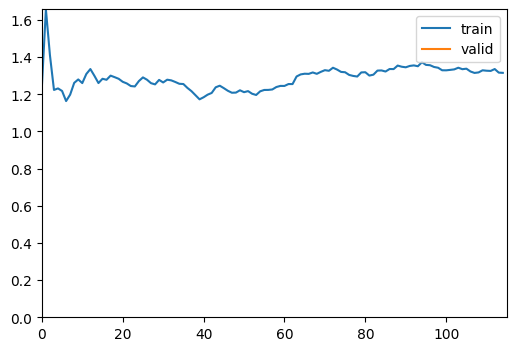

FileNotFoundError: ignored

In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Sigue dando error.

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:04<00:00, 79.1MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.376362,1.009986,0.557484,0.572581,0.591667,0.581967,01:37


Better model found at epoch 0 with valid_loss value: 1.0099855661392212.


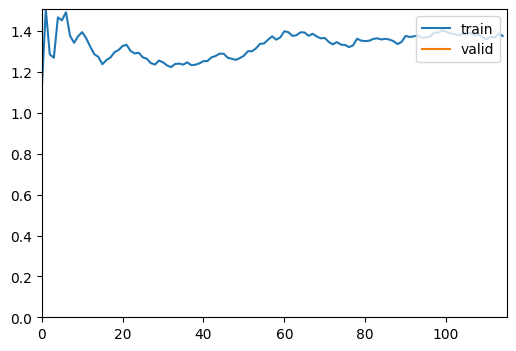

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.099999,0.809445,0.587852,0.587413,0.700000,0.638783,02:02
1,1.044641,0.742330,0.603037,0.610039,0.658333,0.633267,02:03
2,0.972508,0.784720,0.596529,0.585443,0.770833,0.665468,02:03
3,0.988065,0.710840,0.600868,0.595890,0.725000,0.654135,02:02
4,0.942924,0.692587,0.596529,0.616379,0.595833,0.605932,02:03
5,0.915726,0.692445,0.603037,0.589342,0.783333,0.672630,02:03
6,0.849702,0.791567,0.590022,0.573066,0.833333,0.679117,02:02
7,0.809494,0.681677,0.611714,0.591592,0.820833,0.687609,02:02
8,0.791373,0.701945,0.587852,0.630208,0.504167,0.560185,02:02
9,0.766636,0.647140,0.609544,0.611111,0.687500,0.647059,02:03


Better model found at epoch 0 with valid_loss value: 0.8094454407691956.


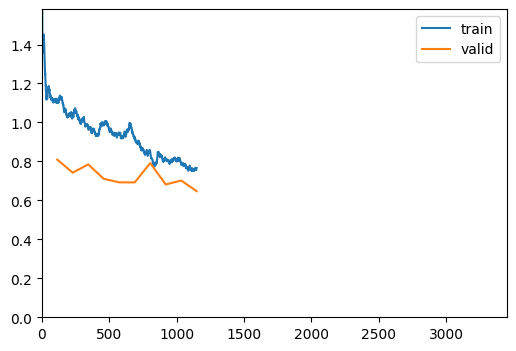

Better model found at epoch 1 with valid_loss value: 0.7423302531242371.
Better model found at epoch 3 with valid_loss value: 0.710840106010437.
Better model found at epoch 4 with valid_loss value: 0.6925873756408691.
Better model found at epoch 5 with valid_loss value: 0.6924451589584351.
Better model found at epoch 7 with valid_loss value: 0.6816770434379578.
Better model found at epoch 9 with valid_loss value: 0.6471402645111084.
No improvement since epoch 7: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 25 minutos.

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.271210,0.992572,0.559653,0.588517,0.512500,0.547884,02:23


Better model found at epoch 0 with valid_loss value: 0.9925723075866699.


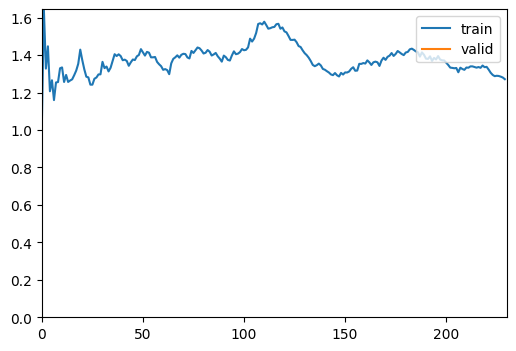

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.167208,0.990542,0.511931,0.568807,0.258333,0.355301,03:08
1,1.060144,0.877576,0.505423,0.536585,0.366667,0.435644,03:10
2,0.997342,0.825949,0.537961,0.570681,0.454167,0.505800,03:10
3,0.961307,0.859933,0.583514,0.600000,0.600000,0.600000,03:09
4,0.898518,0.776846,0.553145,0.577273,0.529167,0.552174,03:09
5,0.822037,0.714520,0.568330,0.600985,0.508333,0.550790,03:10
6,0.790439,0.714123,0.524946,0.558659,0.416667,0.477327,03:11


Better model found at epoch 0 with valid_loss value: 0.9905419945716858.


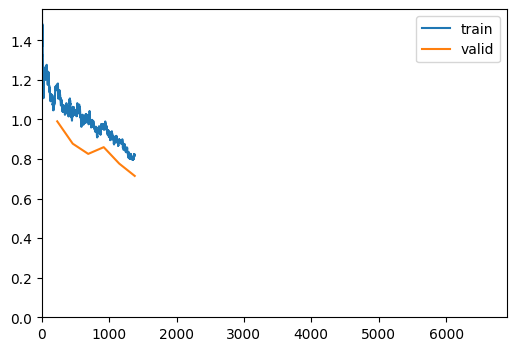

Better model found at epoch 1 with valid_loss value: 0.8775759935379028.
Better model found at epoch 2 with valid_loss value: 0.8259490728378296.
Better model found at epoch 4 with valid_loss value: 0.7768463492393494.
Better model found at epoch 5 with valid_loss value: 0.7145199775695801.
Better model found at epoch 6 with valid_loss value: 0.7141234874725342.
No improvement since epoch 3: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

25 minutos.

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.085783,0.841629,0.553145,0.582524,0.500000,0.538117,00:56


Better model found at epoch 0 with valid_loss value: 0.8416293859481812.


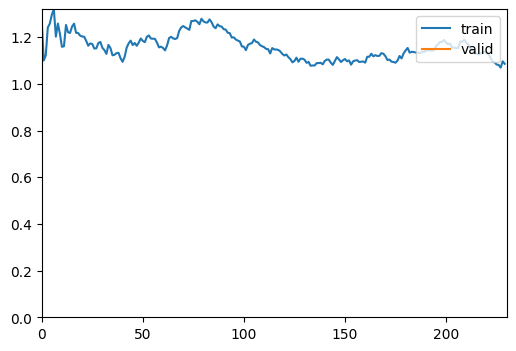

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.948138,0.738734,0.561822,0.593137,0.504167,0.545045,01:13
1,0.948275,0.682456,0.592191,0.600000,0.650000,0.624000,01:13
2,0.841126,0.726983,0.577007,0.596567,0.579167,0.587738,01:15
3,0.910646,0.715202,0.579176,0.630682,0.462500,0.533654,01:13
4,0.807623,0.662178,0.620390,0.643172,0.608333,0.625268,01:13
5,0.786741,0.650281,0.652928,0.694175,0.595833,0.641256,01:13
6,0.731067,0.654595,0.633406,0.678392,0.562500,0.615034,01:13
7,0.648493,0.644583,0.648590,0.657258,0.679167,0.668033,01:13
8,0.628785,0.641841,0.639913,0.677885,0.587500,0.629464,01:11
9,0.650516,0.654436,0.629067,0.648069,0.629167,0.638478,01:11


Better model found at epoch 0 with valid_loss value: 0.738734245300293.


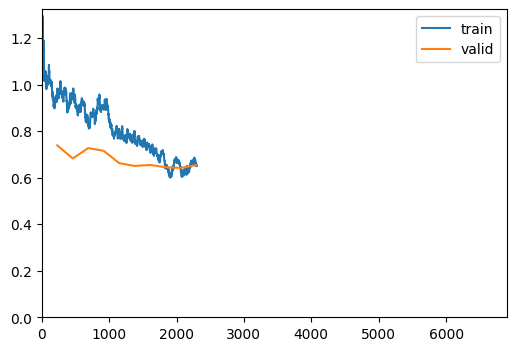

Better model found at epoch 1 with valid_loss value: 0.6824564337730408.
Better model found at epoch 4 with valid_loss value: 0.6621779203414917.
Better model found at epoch 5 with valid_loss value: 0.650280773639679.
Better model found at epoch 7 with valid_loss value: 0.6445826292037964.
Better model found at epoch 8 with valid_loss value: 0.6418411135673523.
Better model found at epoch 10 with valid_loss value: 0.6340940594673157.
No improvement since epoch 7: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

14 minutos y medio.

## Multi-Task

In [21]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dfb2["density"] = enc.fit_transform(np.array(dfb2["density"]).reshape(-1,1))
dfb2["density"]

63       NaN
87       1.0
88       1.0
89       1.0
90       1.0
        ... 
54596    NaN
54599    NaN
54627    1.0
54636    NaN
54642    2.0
Name: density, Length: 2305, dtype: float64

In [22]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3, weights="uniform")
dfb2[dfb2.columns[5:]] = imputer.fit_transform(dfb2[dfb2.columns[5:]])

In [23]:
dfb2[dfb2.columns[5:]] = dfb2[dfb2.columns[5:]].astype(int)
dfb2

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
63,2,10106,190315990,R,MLO,57,0,0,0,0,0,1,21,0
87,1,10130,388811999,L,MLO,71,1,1,1,0,0,1,49,0
88,1,10130,613462606,L,CC,71,1,1,1,0,0,1,49,0
89,1,10130,1360338805,L,CC,71,1,1,1,0,0,1,49,0
90,1,10130,1672636630,L,MLO,71,1,1,1,0,0,1,49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54596,2,9851,1434430689,L,CC,58,1,1,0,0,0,1,48,0
54599,2,9852,948754725,L,CC,58,0,0,0,0,0,1,29,0
54627,1,9894,1991772614,R,CC,50,0,1,0,0,0,1,49,1
54636,2,990,837618473,R,MLO,57,0,0,0,1,0,1,48,0


In [24]:
label = []
for i, row in dfb2.iterrows():
    edad = str(int(row["age"]))
    cancer = str(row["cancer"])
    densidad = str(row["density"])
    if '.' in densidad:
        densidad = densidad[0]
    label.append(edad + ' ' + cancer + ' ' + densidad)
dfb2["label"] = label
dfb2

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,label
63,2,10106,190315990,R,MLO,57,0,0,0,0,0,1,21,0,57 0 1
87,1,10130,388811999,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
88,1,10130,613462606,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
89,1,10130,1360338805,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
90,1,10130,1672636630,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54596,2,9851,1434430689,L,CC,58,1,1,0,0,0,1,48,0,58 1 1
54599,2,9852,948754725,L,CC,58,0,0,0,0,0,1,29,0,58 0 1
54627,1,9894,1991772614,R,CC,50,0,1,0,0,0,1,49,1,50 0 1
54636,2,990,837618473,R,MLO,57,0,0,0,1,0,1,48,0,57 0 1


In [25]:
class MultiTaskDataset():
    def __init__(self, df, tfms, size=64):
        self.paths = []
        for index, row in df.iterrows():
            patient = row["patient_id"]
            image = row["image_id"]
            path = p_under2/str(patient)/(str(image)+'.jpg')
            self.paths.append(path)
        self.labels = list(df["label"])
        self.tfms = tfms
        self.size = size
        self.train = df.copy()
        self.norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #imagenet stats

    def __len__(self): return len(self.paths)

    def __getitem__(self,idx):
        #dealing with the image
        img = PIL.Image.open(self.paths[idx]).convert('RGB')
        img = img.resize((256, 256))
        t = torch.Tensor(np.array(img))
        t = t.permute(2,0,1).float()/255.0
        transform = transforms.ToPILImage()
        img = PILImage(PILImage.create(transform(t)))
        img = self.tfms.encodes(img)
        #img = img.apply_tfms(self.tfms, size = self.size)
        transform = transforms.Compose([transforms.ToTensor()])
        img = self.norm(transform(img))
        #dealing with the labels
        labels = self.labels[idx].split(" ")
        age = torch.tensor(float(labels[0]), dtype=torch.float32)
        cancer = torch.tensor(int(labels[1]), dtype=torch.int64)
        density = torch.tensor(int(labels[2]), dtype=torch.int64)

        return img, (age.log_()/4.75, cancer, density)

    def show(self,idx):
        x, y = self.__getitem__(idx)
        age, cancer, density = y
        stds = np.array([0.229, 0.224, 0.225])
        means = np.array([0.485, 0.456, 0.406])
        img = ((x.numpy().transpose((1,2,0))*stds + means)*255).astype(np.uint8)
        plt.imshow(img)
        plt.title("{} {} {}".format(int(age.mul_(4.75).exp_().item()), cancer.item(), density.item()))

In [41]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(dfb2, test_size=0.2)

tfms = aug_transforms()
tdset = MultiTaskDataset(train, tfms[0], size=64)
vdset = MultiTaskDataset(test, tfms[1], size=64)
data = DataLoaders.from_dsets(tdset, vdset, batch_size=4, shuffle=True, device=torch.device('cuda'))

In [27]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [28]:
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, task_num):
        super(MultiTaskLossWrapper, self).__init__()
        self.task_num = task_num
        self.log_vars = nn.Parameter(torch.zeros((task_num)))

    def forward(self, preds, label):

        mse, crossEntropy = MSELossFlat(), CrossEntropyLossFlat()

        loss0 = mse(preds[0], label[0])
        loss1 = crossEntropy(preds[1], label[1])
        loss2 = crossEntropy(preds[2], label[2])

        precision0 = torch.exp(-self.log_vars[0])
        loss0 = precision0*loss0 + self.log_vars[0]

        precision1 = torch.exp(-self.log_vars[1])
        loss1 = precision1*loss1 + self.log_vars[1]

        precision2 = torch.exp(-self.log_vars[2])
        loss2 = precision2*loss2 + self.log_vars[2]

        return loss0+loss1+loss2

In [42]:
from sklearn.metrics import f1_score
def rmse_age(preds, labels): return rmse(preds[0], labels[0])
def f1_cancer(preds, labels):
    pred = preds[1].cpu()
    pred = np.array(pred)
    plist = []
    for i in range(len(pred)):
        if np.sum(pred[i]) > 0:
            plist.append(1)
        else:
            plist.append(0)
    return f1_score(np.array(plist), labels[1].cpu())
def acc_density(preds, labels): return accuracy(preds[2], labels[2])

metrics = [rmse_age, f1_cancer, acc_density]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_func = MultiTaskLossWrapper(3).to(device) #just making sure the loss is on the gpu

## Modelos Multi-Task

### ResNet

In [43]:
model = MultiTaskModel(resnet50(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=ShowGraphCallback(), metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time


RuntimeError: ignored

### EfficientNet

In [44]:
model = MultiTaskModel(efficientnet_b3(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=ShowGraphCallback(), metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time


RuntimeError: ignored

### ConvNext

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.282263,1.841826,0.047397,0.284599,0.585683,02:26


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


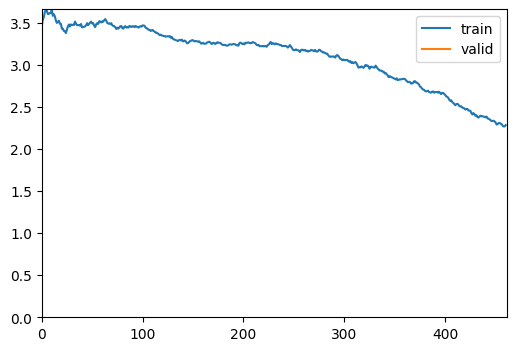

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,1.833879,1.685501,0.039911,0.207086,0.585683,02:25
1,1.662946,1.660983,0.040379,0.398967,0.594360,02:23
2,1.670107,1.628615,0.043986,0.528602,0.622560,02:26
3,1.731835,1.697952,0.040434,0.482677,0.609544,02:25
4,1.756305,1.675064,0.043396,0.194360,0.581345,02:24
5,1.703065,1.775674,0.040759,0.534903,0.446855,02:25
6,1.754782,2.498504,0.061041,0.336205,0.373102,02:25
7,1.767774,1.626776,0.039275,0.102386,0.622560,02:24
8,1.599607,1.698243,0.038967,0.274104,0.603037,02:25
9,1.783875,1.976109,0.066233,0.620349,0.546638,02:25


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


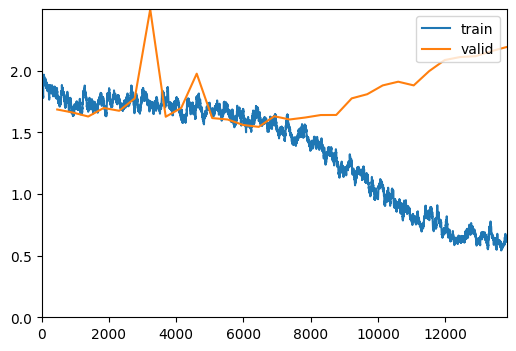

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics

In [ ]:
model = MultiTaskModel(convnext_base(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=ShowGraphCallback(), metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

### HRNet

In [51]:
model = MultiTaskModel(timm.models.hrnet_w44(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=ShowGraphCallback(), metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time


NotImplementedError: ignored

### Deit

In [52]:
model = MultiTaskModel(timm.models.deit3_base_patch16_384(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=ShowGraphCallback(), metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

StopIteration: ignored

## Procesamiento de datos

In [ ]:
dfb

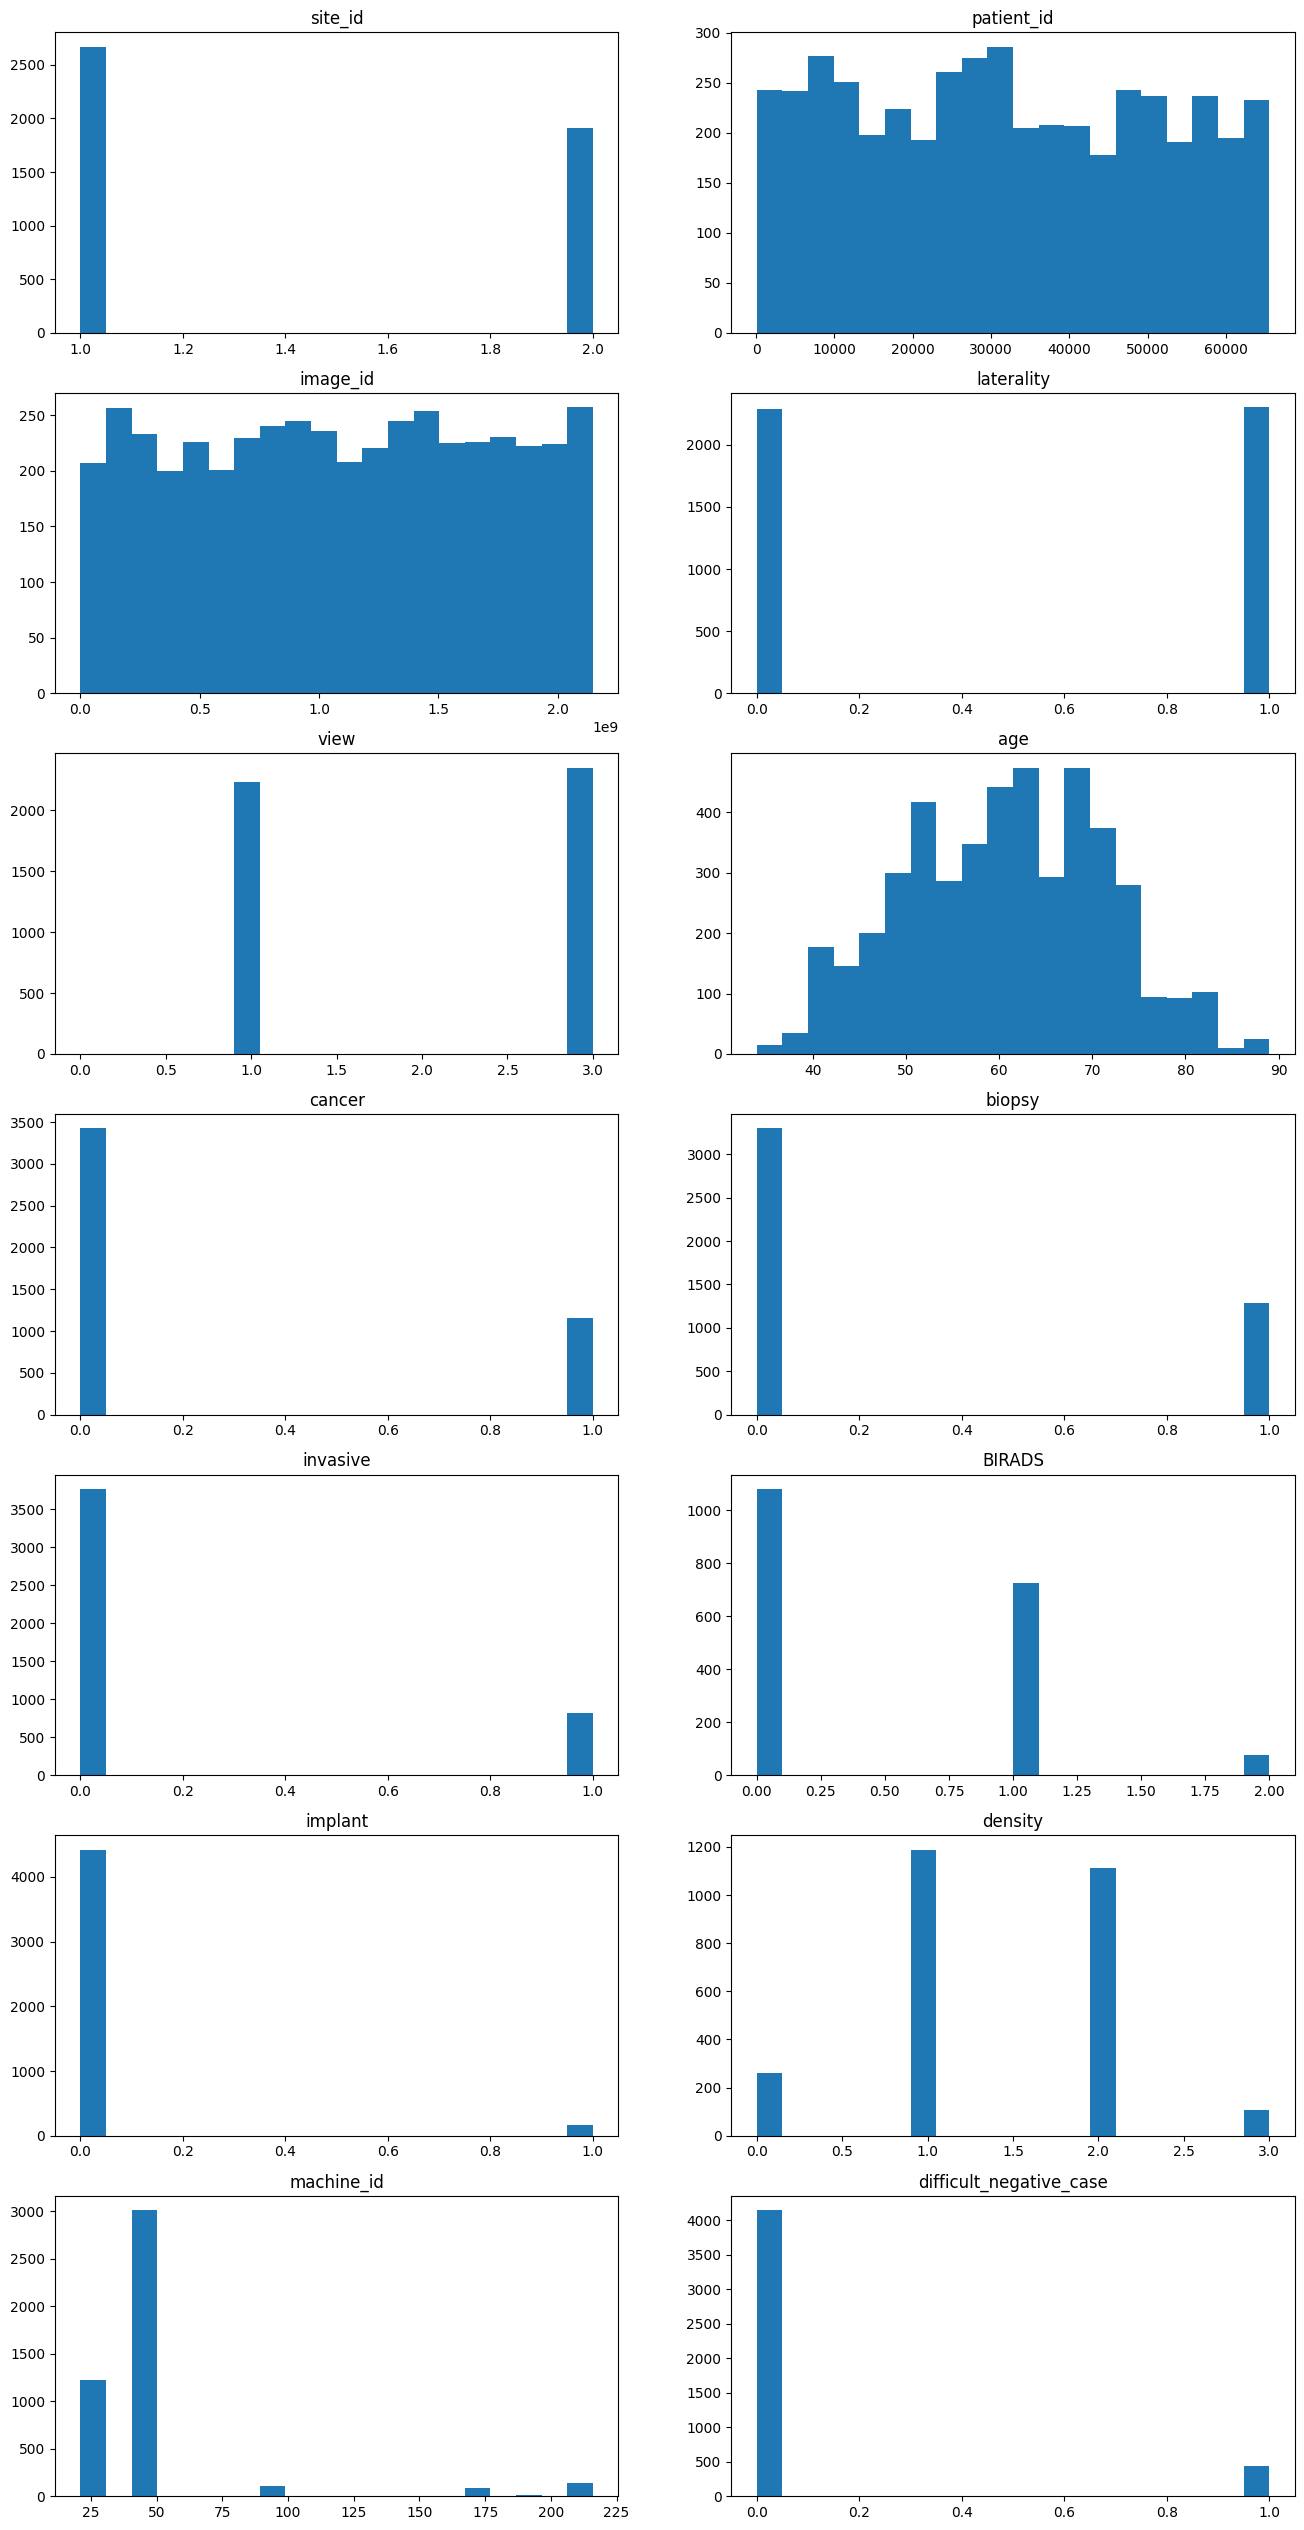

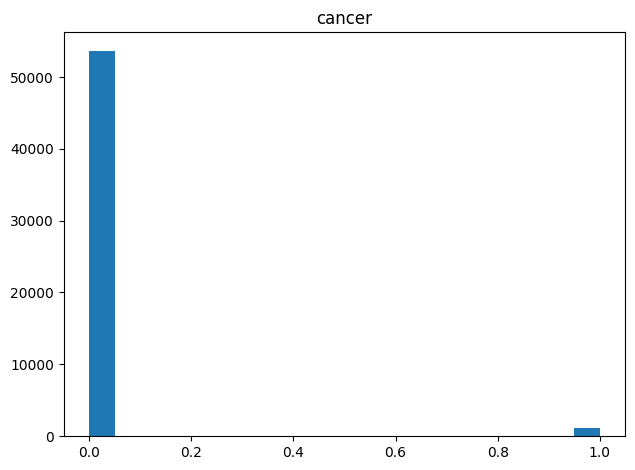

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
dfb2 = dfb.copy()
enc = OrdinalEncoder()
dfb2[["laterality","view","density","difficult_negative_case"]] = enc.fit_transform(dfb2[["laterality","view","density","difficult_negative_case"]])
fig, axes = plt.subplots(7, 2, figsize = (16, 32))
axes[0,0].hist(dfb2["site_id"].values, bins = 20)
axes[0,0].set_title("site_id")
axes[0,1].hist(dfb2["patient_id"].values, bins = 20)
axes[0,1].set_title("patient_id")
axes[1,0].hist(dfb2["image_id"].values, bins = 20)
axes[1,0].set_title("image_id")
axes[1,1].hist(dfb2["laterality"].values, bins = 20)
axes[1,1].set_title("laterality")
axes[2,0].hist(dfb2["view"].values, bins = 20)
axes[2,0].set_title("view")
axes[2,1].hist(dfb2["age"].values, bins = 20)
axes[2,1].set_title("age")
axes[3,0].hist(dfb2["cancer"].values, bins = 20)
axes[3,0].set_title("cancer")
axes[3,1].hist(dfb2["biopsy"].values, bins = 20)
axes[3,1].set_title("biopsy")
axes[4,0].hist(dfb2["invasive"].values, bins = 20)
axes[4,0].set_title("invasive")
axes[4,1].hist(dfb2["BIRADS"].values, bins = 20)
axes[4,1].set_title("BIRADS")
axes[5,0].hist(dfb2["implant"].values, bins = 20)
axes[5,0].set_title("implant")
axes[5,1].hist(dfb2["density"].values, bins = 20)
axes[5,1].set_title("density")
axes[6,0].hist(dfb2["machine_id"].values, bins = 20)
axes[6,0].set_title("machine_id")
axes[6,1].hist(dfb2["difficult_negative_case"].values, bins = 20)
axes[6,1].set_title("difficult_negative_case")
plt.show()

plt.figure(figsize = (7.25, 5.25))
plt.title("cancer")
plt.hist(y.values, bins = 20)
plt.show()